# QProfiler on the CD4-vs-CD8 T-cell task (with PQK)

Benchmarks classical models and the **projected quantum kernel (PQK)** on the one
*non-trivial* single-cell binary task: **CD4 vs CD8 T cells**.

The other two tasks built earlier (`t_vs_mono`, `lymphoid_vs_myeloid`) are near-perfectly
separable — every model saturates at ~1.0, so they can't discriminate methods, which is
why we focus on **CD4 vs CD8** here.

**How to use:** set models / embeddings / PQK options in the **Configuration** cell and run
top-to-bottom. Classical models finish in seconds; PQK runs on the local statevector
simulator with a shallow, tuned feature map that keeps it fast (see §5).

---

> **Results changed in this release.** These outputs were produced before QProfiler's
> train/test contamination was fixed: the feature scaler used to be fit on
> `concat([X_train, X_test])`, so the test distribution informed the transform, and the
> train/test split was unseeded, so `seed` did not make a run reproducible. Both are fixed
> (`scale_train_test` fits on train only; the split takes `random_state=seed + iteration`).
> Numbers below are therefore **not comparable** to a fresh run of the same config — the
> corrected numbers are usually slightly lower, which is the point. See `CHANGELOG.md`.


## 1. Setup and imports

In [1]:
import os
import sys
import json
import shutil
import glob
import yaml
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

import qbiocode as qbc
from qbiocode.apps.qprofiler import qprofiler as profiler
from qbiocode import compute_results_correlation, plot_results_correlation

sns.set_style("whitegrid")

# ---- Portable paths (relative to this notebook; run it from its own directory) ----
NB_DIR = os.getcwd()                                    # this notebook's own directory
DATA_DIR = os.path.join(NB_DIR, "data", "sc_binary")    # per-task CSVs (shipped + rebuildable)
H5AD_DIR = os.path.join(NB_DIR, "data")                 # source h5ads for optional rebuild
CONFIG_TEMPLATE = os.path.join(NB_DIR, "configs", "config.yaml")
OUT_DIR = NB_DIR                                        # ModelResults.csv etc. land here

os.makedirs(DATA_DIR, exist_ok=True)
# QProfiler writes outputs to the current working directory -> pin it to OUT_DIR.
os.chdir(OUT_DIR)
print("qbiocode", qbc.__version__)
print("cwd (outputs):", os.getcwd())

<env>/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


qbiocode 0.1.0
cwd (outputs): <repo>/docs/source/tutorials/QProfiler


## 2. Configuration — choose task, modality, models, embeddings

Everything you'd normally tweak lives here.

- `TASK`: one of the three tasks, or `"all"` to benchmark all three (needed for the
  cross-task complexity correlation).
- `MODALITY`: what features feed the pipeline —
  - `"hvg"` — **gene expression** (the original behavior): top-`N_FEATURES` high-variance HVGs.
  - `"adt"` — **protein**: the 32 scaled TotalSeqB ADT markers from the h5ad's CITE-seq layer
    (`obsm['X_protein']`). Leakage-safe drops the 6 lineage-defining proteins → 26 markers.
  - `"hvg+adt"` — **early fusion**: concatenate the top-`N_FEATURES` HVGs with all non-leakage
    ADTs into one feature table (columns prefixed `rna:` / `adt:`), then run the same pipeline.

  ADT and fusion read the protein layer, which only ships in `pbmc5k_small_cd4_vs_cd8.h5ad`, so
  those modalities apply to **`cd4_vs_cd8` only** (`t_vs_mono` / `lymphoid_vs_myeloid` stay HVG).
- `LEAKAGE_SAFE`: drop the lineage-defining markers that trivially reveal the label — genes
  (e.g. `CD3D`, `LYZ`, `MS4A1`) and, for ADT/fusion, proteins (`CD3`, `CD4`, `CD8a`, …).
  Recommended — otherwise classification is trivial.
- `N_FEATURES`: number of top-variance HVGs exported (also the HVG portion of the fusion). Kept
  small so complexity metrics and QML stay light on a laptop.
- `MODELS`: classical `svc dt lr nb rf mlp` (fast) and/or quantum `qsvc pqk vqc qnn`
  (slow on the local simulator).

In [2]:
# ============================ EXPERIMENT CONFIG ============================
# Focus on CD4 vs CD8 -- the only discriminative task (the other two saturate at ~1.0).
TASK = "cd4_vs_cd8"
LEAKAGE_SAFE = True   # drop label-defining marker genes/proteins
N_FEATURES = 50       # top-variance HVGs to export per task (keeps compute light)

# Input modality -- what features feed the pipeline. ADT/fusion need the h5ad's CITE-seq
# protein layer, which only ships for cd4_vs_cd8, so they apply to that task only.
#   "hvg"     -> gene expression: top-N_FEATURES high-variance HVGs (the original behavior)
#   "adt"     -> protein: the 32 scaled TotalSeqB ADT markers (leakage-safe drops 6 -> 26)
#   "hvg+adt" -> early fusion: concat top-N_FEATURES HVGs + all non-leakage ADTs (~N+26 cols)
MODALITY = "hvg"      # "hvg" | "adt" | "hvg+adt"

MODELS = ["lr", "svc", "rf", "mlp", "pqk"]   # classical baselines + projected quantum kernel
EMBEDDINGS = ["pca"]  # e.g. ["none"], ["pca","isomap"]
N_COMPONENTS = 8      # dims after embedding (= qubit count for PQK)
ITER = 5              # train/test splits per model-embedding
TEST_SIZE = 0.3

# PQK feature-map tuning. The shipped template uses a DEEP ZZ map (pairwise, reps=4) that
# suffers quantum-kernel *concentration*: the <X>,<Y>,<Z> projections collapse toward 0, so
# the kernel carries little signal (and it is slow). A SHALLOW, linearly-entangled ZZ map
# (reps=1) fixes both -- on cd4_vs_cd8 it lifts PQK accuracy ~0.81 -> ~0.88 and is ~3x faster.
PQK_ARGS = {"encoding": "ZZ", "entanglement": "linear", "primitive": "estimator", "reps": 1}

# ---- Quantum backend --------------------------------------------------------------------
# USE_HARDWARE=False -> local statevector simulator (default; no credentials, runs anywhere).
# USE_HARDWARE=True  -> run the QML models on IBM Quantum HARDWARE. HW_BACKEND picks the device
#   and configs/credentials.json supplies only the QiskitRuntimeService auth (channel / instance
#   / token / url). Copy configs/credentials.example.json -> configs/credentials.json and fill it
#   in first (credentials.json is gitignored, so the token is never committed).
USE_HARDWARE = False
HW_BACKEND = "ibm_least"   # device when USE_HARDWARE=True: "ibm_least" (least-busy real device),
                           # a named device e.g. "ibm_torino", "simulator_aer", or "noisy_<device>"
CREDENTIALS_PATH = os.path.join(NB_DIR, "configs", "credentials.json")
# ===========================================================================

ALL_TASKS = ["t_vs_mono", "lymphoid_vs_myeloid", "cd4_vs_cd8"]
ALL_MODALITIES = ["hvg", "adt", "hvg+adt"]
assert TASK in ALL_TASKS, f"unknown TASK {TASK!r}"
assert MODALITY in ALL_MODALITIES, f"unknown MODALITY {MODALITY!r}"
print("Task:", TASK, "| Modality:", MODALITY, "| Models:", MODELS)
print("Embeddings:", EMBEDDINGS, "| n_components:", N_COMPONENTS, "| iters:", ITER)
print("PQK_ARGS:", PQK_ARGS)
print("Backend:", f"IBM Quantum HARDWARE ({HW_BACKEND})" if USE_HARDWARE else "local simulator")

Task: cd4_vs_cd8 | Modality: hvg | Models: ['lr', 'svc', 'rf', 'mlp', 'pqk']
Embeddings: ['pca'] | n_components: 8 | iters: 5
PQK_ARGS: {'encoding': 'ZZ', 'entanglement': 'linear', 'primitive': 'estimator', 'reps': 1}
Backend: local simulator


## 3. Build per-task CSV datasets

QProfiler reads plain CSVs (features in columns, **label in the last column**). We export
one CSV per task from the small balanced h5ads (500 cells, 250/class), with columns chosen by
`MODALITY`:

- `"hvg"` — top-`N_FEATURES` high-variance HVGs (optionally excluding label-defining marker
  genes to avoid leakage).
- `"adt"` — the scaled TotalSeqB ADT markers from `obsm['X_protein']` (leakage-safe drops the
  6 lineage-defining proteins → 26).
- `"hvg+adt"` — early fusion: the HVG block and the ADT block concatenated side by side, with
  columns prefixed `rna:` / `adt:`.

Files are named `pbmc-<task>.csv` so they share the `pbmc` datatype prefix, which lets
QProfiler correlate complexity to performance **across** the three tasks (HVG modality only —
ADT/fusion build `cd4_vs_cd8` alone). Switching `MODALITY` rebuilds the same file with the new
column set.

In [3]:
def _select_hvgs(adata, n_features, leakage_safe):
    """Return (X, names) for the top-`n_features` high-variance HVGs (leakage-safe optional)."""
    keep = adata.var["highly_variable"].to_numpy().copy()
    if leakage_safe and "is_label_leakage" in adata.var:
        keep &= ~adata.var["is_label_leakage"].to_numpy()
    X = adata[:, keep].X
    X = np.asarray(X.todense()) if hasattr(X, "todense") else np.asarray(X)
    genes = adata.var_names[keep].to_numpy()
    order = np.argsort(X.var(axis=0))[::-1][:n_features]   # rank by variance, take top-N
    return X[:, order], genes[order]


def _select_adts(adata, leakage_safe):
    """Return (X, names) for the scaled ADT markers in obsm['X_protein'] (leakage-safe optional).

    All non-leakage markers are kept (there are only ~32), so there is no top-N cap here.
    """
    if "X_protein" not in adata.obsm or "protein_names" not in adata.uns:
        raise KeyError("h5ad has no CITE-seq protein layer (obsm['X_protein'] / uns['protein_names'])")
    X = np.asarray(adata.obsm["X_protein"])
    names = np.asarray(adata.uns["protein_names"], dtype=object)
    keep = np.ones(len(names), dtype=bool)
    if leakage_safe:
        leak = set(adata.uns.get("feature_sets", {}).get("label_leakage_proteins", []))
        keep = np.array([nm not in leak for nm in names])
    return X[:, keep], names[keep]


def export_task_csv(task, n_features, leakage_safe, modality, data_dir, h5ad_dir):
    """Write pbmc-<task>.csv (features + label) for the chosen modality and return (path, info).

    modality: "hvg" (genes), "adt" (proteins), or "hvg+adt" (early-fusion concatenation).
    Fusion columns are prefixed rna:/adt: to avoid gene/protein name collisions. In every
    case the label MUST be the last column (QProfiler reads it positionally).
    """
    adata = ad.read_h5ad(os.path.join(h5ad_dir, f"pbmc5k_small_{task}.h5ad"))

    if modality == "hvg":
        X, names = _select_hvgs(adata, n_features, leakage_safe)
        n_hvg, n_adt = X.shape[1], 0
    elif modality == "adt":
        X, names = _select_adts(adata, leakage_safe)
        n_hvg, n_adt = 0, X.shape[1]
    elif modality == "hvg+adt":                                # early fusion: concat both blocks
        Xg, genes = _select_hvgs(adata, n_features, leakage_safe)
        Xp, prots = _select_adts(adata, leakage_safe)
        X = np.concatenate([Xg, Xp], axis=1)
        names = np.array([f"rna:{g}" for g in genes] + [f"adt:{p}" for p in prots], dtype=object)
        n_hvg, n_adt = Xg.shape[1], Xp.shape[1]
    else:
        raise ValueError(f"unknown modality {modality!r}")

    df = pd.DataFrame(X, columns=list(names))
    df["label"] = adata.obs["label"].astype(str).to_numpy()    # label MUST be last column

    path = os.path.join(data_dir, f"pbmc-{task}.csv")
    df.to_csv(path, index=False)
    info = {"task": task, "modality": modality, "n_cells": df.shape[0],
            "n_features": X.shape[1], "n_hvg": n_hvg, "n_adt": n_adt,
            "classes": df["label"].value_counts().to_dict()}
    return path, info


def _h5ad_has_protein(h5ad_path):
    """True if the h5ad carries a CITE-seq protein layer (needed for adt / hvg+adt)."""
    if not os.path.exists(h5ad_path):
        return False
    a = ad.read_h5ad(h5ad_path, backed="r")
    return "X_protein" in a.obsm and "protein_names" in a.uns


# Rebuild each task's CSV for the chosen MODALITY.
#   "hvg":     rebuild from the h5ad when present; otherwise reuse the CSV shipped in DATA_DIR.
#   "adt"/"hvg+adt": require the h5ad's protein layer, so only tasks that have one are built;
#                    others are skipped (only pbmc5k_small_cd4_vs_cd8.h5ad ships that layer).
for t in ALL_TASKS:
    h5ad = os.path.join(H5AD_DIR, f"pbmc5k_small_{t}.h5ad")
    csv = os.path.join(DATA_DIR, f"pbmc-{t}.csv")
    if MODALITY == "hvg":
        if os.path.exists(h5ad):
            _, info = export_task_csv(t, N_FEATURES, LEAKAGE_SAFE, MODALITY, DATA_DIR, H5AD_DIR)
            print("rebuilt from h5ad:", info)
        else:
            assert os.path.exists(csv), (
                f"no h5ad and no pre-built CSV for {t}; "
                f"add pbmc5k_small_{t}.h5ad to {H5AD_DIR} to build it")
            print(f"using shipped CSV (no h5ad for {t}):", os.path.basename(csv))
    else:  # adt / hvg+adt need the protein layer
        if _h5ad_has_protein(h5ad):
            _, info = export_task_csv(t, N_FEATURES, LEAKAGE_SAFE, MODALITY, DATA_DIR, H5AD_DIR)
            print("rebuilt from h5ad:", info)
        else:
            print(f"skipping {t}: MODALITY={MODALITY!r} needs a CITE-seq protein layer "
                  f"(only cd4_vs_cd8 ships one)")

# The selected task must exist as a CSV after the loop (fails loudly for an unbuildable request,
# e.g. MODALITY='adt' on a task with no protein layer).
if TASK != "all":
    sel = os.path.join(DATA_DIR, f"pbmc-{TASK}.csv")
    assert os.path.exists(sel), (
        f"MODALITY={MODALITY!r} could not build {TASK!r} (no CITE-seq protein layer). "
        f"Use MODALITY='hvg', or pick a task whose h5ad has obsm['X_protein'].")

print("\nCSVs in", DATA_DIR, "->",
      sorted(os.path.basename(p) for p in glob.glob(DATA_DIR + "/*.csv")))

using shipped CSV (no h5ad for t_vs_mono): pbmc-t_vs_mono.csv
using shipped CSV (no h5ad for lymphoid_vs_myeloid): pbmc-lymphoid_vs_myeloid.csv
rebuilt from h5ad: {'task': 'cd4_vs_cd8', 'modality': 'hvg', 'n_cells': 500, 'n_features': 50, 'n_hvg': 50, 'n_adt': 0, 'classes': {'CD4_T': 250, 'CD8_T': 250}}

CSVs in <repo>/docs/source/tutorials/QProfiler/data/sc_binary -> ['pbmc-cd4_vs_cd8.csv', 'pbmc-lymphoid_vs_myeloid.csv', 'pbmc-t_vs_mono.csv']


## 4. Assemble the QProfiler config

We start from the shipped YAML template and override our choices, then resolve the **quantum
backend** from the `USE_HARDWARE` flag:

- `USE_HARDWARE = False` (default) → `backend = "simulator"`: the local statevector simulator.
  No credentials needed; runs anywhere.
- `USE_HARDWARE = True` → run the QML models on **IBM Quantum hardware**. The **device** is
  chosen in the notebook via `HW_BACKEND` (`"ibm_least"` auto-picks the least-busy real device,
  or name one directly, e.g. `"ibm_torino"`); `configs/credentials.json` supplies only the
  `QiskitRuntimeService` **auth**. First copy the template and fill it in:

  ```bash
  cp configs/credentials.example.json configs/credentials.json
  # then edit credentials.json: channel / instance / token / url
  ```

  `apply_backend()` sets `config["backend"] = HW_BACKEND` and injects the auth as the
  `ibm_channel/ibm_instance/ibm_token/ibm_url` args that qbiocode's `get_creds()` consumes.
  `credentials.json` is **gitignored**, so your API token is never committed.

In [4]:
# Start from the shipped template (keeps all model-arg blocks) and override our choices.
config = yaml.safe_load(open(CONFIG_TEMPLATE))

config.update({
    "folder_path": os.path.abspath(DATA_DIR),   # absolute -> independent of cwd
    "file_dataset": "ALL" if TASK == "all" else [f"pbmc-{TASK}.csv"],
    "model": MODELS,
    "embeddings": EMBEDDINGS,
    "n_components": N_COMPONENTS,
    "iter": ITER,
    "test_size": TEST_SIZE,
    "stratify": ["y"],
    "scaling": ["True"],
    "n_jobs": 1,
    "grid_search": False,
})
config["pqk_args"] = PQK_ARGS   # tuned shallow ZZ map (overrides the template default)


def apply_backend(config, use_hardware, hw_backend, credentials_path):
    """Set config['backend'] (and, for hardware, the IBM Quantum credentials) in place.

    The device is chosen in the notebook via hw_backend; credentials.json supplies only the
    QiskitRuntimeService auth (channel/instance/token/url), injected as the args that qbiocode's
    get_creds() / get_backend_session() consume. Returns the resolved backend string.
    """
    if not use_hardware:
        config["backend"] = "simulator"
        return config["backend"]

    config["backend"] = hw_backend   # device is set in the notebook, not in credentials.json

    assert os.path.exists(credentials_path), (
        f"USE_HARDWARE=True but no credentials file at {credentials_path}.\n"
        f"Copy configs/credentials.example.json -> configs/credentials.json and fill in "
        f"your IBM Quantum channel / instance / token / url.")
    with open(credentials_path) as f:
        creds = json.load(f)
    missing = [k for k in ("channel", "instance", "token", "url") if not creds.get(k)]
    assert not missing, f"credentials.json is missing required field(s): {missing}"

    # QiskitRuntimeService creds -> the arg names qbiocode.utils.ibm_account.get_creds() reads.
    config["ibm_channel"] = creds["channel"]
    config["ibm_instance"] = creds["instance"]
    config["ibm_token"] = creds["token"]
    config["ibm_url"] = creds["url"]
    config["name"] = None            # use the explicit token, not a saved-account alias
    config["qiskit_json_path"] = None  # rely solely on credentials.json (not ~/.qiskit/...)
    # sim_method is only read by the aer / noisy_* backends; harmless for real hardware.
    config["sim_method"] = creds.get("sim_method", "statevector")
    return config["backend"]


backend = apply_backend(config, USE_HARDWARE, HW_BACKEND, CREDENTIALS_PATH)

print("file_dataset:", config["file_dataset"])
print("models:", config["model"], "| embeddings:", config["embeddings"])
print("pqk_args:", config["pqk_args"])
if USE_HARDWARE:
    print(f"backend: {backend}  (IBM Quantum hardware; instance={config['ibm_instance']})")
else:
    print(f"backend: {backend}  (local statevector simulator)")

file_dataset: ['pbmc-cd4_vs_cd8.csv']
models: ['lr', 'svc', 'rf', 'mlp', 'pqk'] | embeddings: ['pca']
pqk_args: {'encoding': 'ZZ', 'entanglement': 'linear', 'primitive': 'estimator', 'reps': 1}
backend: simulator  (local statevector simulator)


## 5. Run QProfiler

QProfiler writes/appends to `ModelResults.csv`, `RawDataEvaluation.csv`, and `results.pkl`
in the working directory, so we clear any stale outputs first (otherwise rows accumulate
across runs).

In [5]:
# Clear stale outputs so results reflect only this run.
for f in ["ModelResults.csv", "RawDataEvaluation.csv", "results.pkl"]:
    if os.path.exists(f):
        os.remove(f)
# PQK's projection cache keys on the feature-map parameters (encoding, entanglement,
# reps, primitive) as well as dataset/embedding/iteration, so a feature-map change no
# longer reloads stale projections. Purged anyway, to keep this run self-contained.
shutil.rmtree("pqk_projections", ignore_errors=True)

profiler.main(config)

model_results = pd.read_csv("ModelResults.csv")
print("ModelResults:", model_results.shape,
      "| datasets:", model_results["Dataset"].unique().tolist())
model_results[["Dataset", "model", "embeddings", "iteration",
               "accuracy", "f1_score", "auc"]].head(12)

Processing file: pbmc-cd4_vs_cd8.csv


at datapoint 0


at datapoint 100


at datapoint 200


at datapoint 300


...

at datapoint 300


at datapoint 0


at datapoint 100


ModelResults: (25, 32) | datasets: ['pbmc-cd4_vs_cd8.csv']


,Dataset,model,embeddings,iteration,accuracy,f1_score,auc
0,pbmc-cd4_vs_cd8.csv,lr,pca,1,0.893333,0.892646,0.893333
1,pbmc-cd4_vs_cd8.csv,mlp,pca,1,0.880000,0.879915,0.880000
2,pbmc-cd4_vs_cd8.csv,pqk,pca,1,0.900000,0.899960,0.900000
3,pbmc-cd4_vs_cd8.csv,rf,pca,1,0.893333,0.893029,0.893333
4,pbmc-cd4_vs_cd8.csv,svc,pca,1,0.860000,0.858178,0.860000
5,pbmc-cd4_vs_cd8.csv,lr,pca,2,0.860000,0.859494,0.860000
6,pbmc-cd4_vs_cd8.csv,mlp,pca,2,0.866667,0.866667,0.866667
7,pbmc-cd4_vs_cd8.csv,pqk,pca,2,0.860000,0.859994,0.860000
8,pbmc-cd4_vs_cd8.csv,rf,pca,2,0.833333,0.832731,0.833333
9,pbmc-cd4_vs_cd8.csv,svc,pca,2,0.820000,0.817658,0.820000


## 6. Visualize model performance

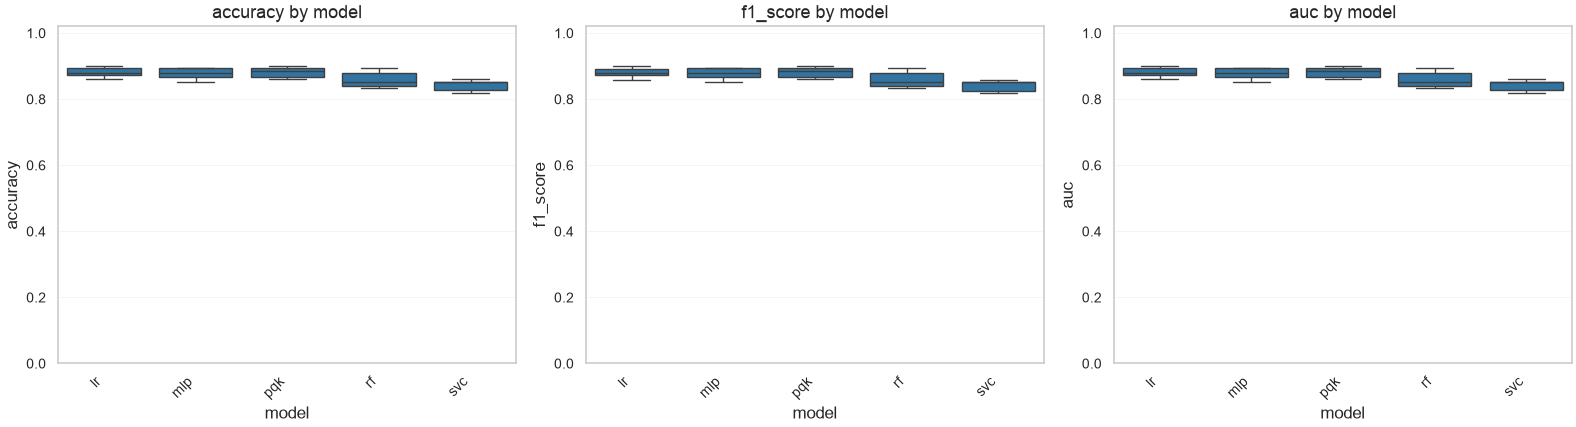

,accuracy,f1_score,auc
model,,,
lr,0.880,0.879,0.880
mlp,0.880,0.880,0.880
pqk,0.887,0.886,0.887
rf,0.853,0.853,0.853
svc,0.853,0.851,0.853


In [6]:
metrics = ["accuracy", "f1_score", "auc"]
multi_ds = model_results["Dataset"].nunique() > 1

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric in zip(axes, metrics):
    if multi_ds:
        sns.boxplot(data=model_results, x="model", y=metric, hue="Dataset", ax=ax)
        ax.legend_.set_title("task") if ax.legend_ else None
    else:
        sns.boxplot(data=model_results, x="model", y=metric, ax=ax)
    ax.set_title(f"{metric} by model")
    ax.set_ylim(0, 1.02)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    if multi_ds and ax is not axes[-1] and ax.legend_:
        ax.legend_.remove()
plt.tight_layout()
plt.show()

# Compact summary table: median metric per model (x task if multiple)
grp = ["Dataset", "model"] if multi_ds else ["model"]
summary = (model_results.groupby(grp)[metrics].median().round(3))
summary

## 7. Classical vs quantum: performance and behaviour

Two complementary views of how the projected quantum kernel (**PQK**) compares with the
**single best classical model** — the classical classifier with the highest median F1, not
an average over the classical methods — in one publication figure.

**Panel A — performance.** PQK against the best classical model across accuracy, F1 and AUC:
the marker is the mean, whiskers the 95% CI over the 5 splits, and faint dots the individual
splits. PQK sits a touch above its strongest classical competitor on all three metrics, but
the intervals overlap — a small, not decisive, edge.

**Panel B — behaviour.** Using QBioCode's `compute_results_correlation`, we take each model's
per-split Spearman ρ between a data-complexity characteristic and F1, then plot
**Δρ = ρ(PQK) − ρ(best classical)** for the characteristics where the two diverge most
(|Δρ| ≥ 0.3). Purple bars = PQK's F1 tracks that characteristic *more positively* than the
best classical model; blue = *less*. This is where quantum and classical "look at" the data
differently — the annotation on each bar gives the underlying `best-classical → PQK` ρ.

> ⚠️ **Power note.** Each split is one point, so both panels rest on **n = 5** — read the
> *direction and size* of the gap, not p-values. A robust classical-vs-quantum claim needs a
> *panel of datasets* spanning complexity.

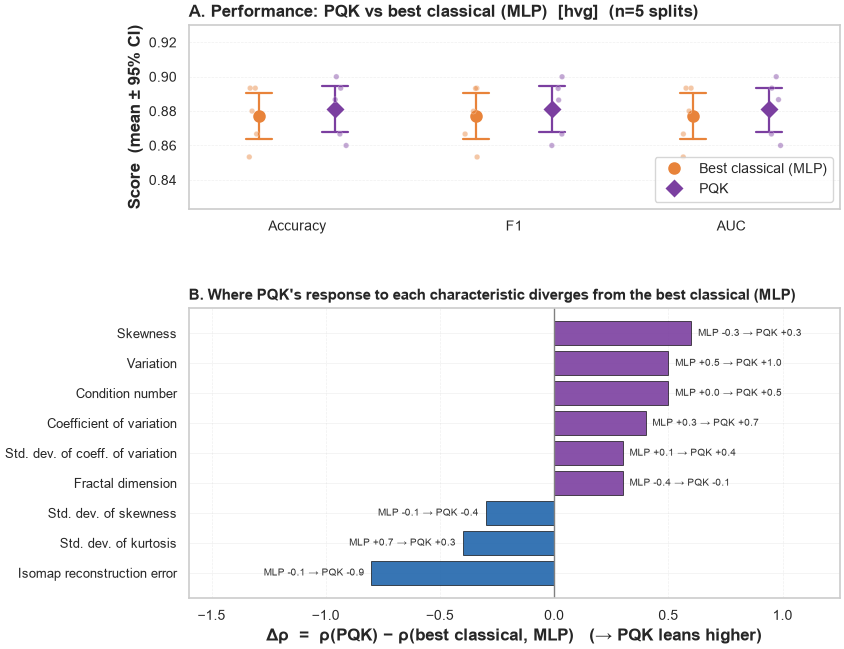

,classical,quantum,delta
Isomap reconstruction error,-0.1,-0.9,-0.8
Std. dev. of kurtosis,0.7,0.3,-0.4
Std. dev. of skewness,-0.1,-0.4,-0.3
Fractal dimension,-0.4,-0.1,0.3
Std. dev. of coeff. of variation,0.1,0.4,0.3
Coefficient of variation,0.3,0.7,0.4
Condition number,0.0,0.5,0.5
Variation,0.5,1.0,0.5
Skewness,-0.3,0.3,0.6


In [7]:
# Classical vs quantum, two ways in one figure. The classical baseline is the SINGLE BEST
# classical model (highest median F1), not an average across classical methods.
#   Panel A — performance: PQK vs best classical across accuracy/F1/AUC (mean ± 95% CI, points).
#   Panel B — behaviour: how PQK's per-split correlation to each data characteristic diverges
#             from the best classical  (Δρ = ρ_PQK − ρ_best-classical).
from matplotlib.gridspec import GridSpec

df7 = model_results[model_results["Dataset"].str.contains("cd4_vs_cd8")].copy()
QUANTUM = {"pqk", "qsvc", "vqc", "qnn"}
present = df7["model"].unique().tolist()
CLASSICAL = [m for m in present if m not in QUANTUM]
QUANT = next(m for m in present if m in QUANTUM)          # PQK here
QLABEL = QUANT.upper()
BEST_CLS = df7[df7["model"].isin(CLASSICAL)].groupby("model")["f1_score"].median().idxmax()
BLABEL = f"Best classical ({BEST_CLS.upper()})"
CCOL, QCOL, NEG = "#E8833A", "#7B3FA0", "#2166AC"
METLAB = {"accuracy": "Accuracy", "f1_score": "F1", "auc": "AUC"}

# ---- Panel A data: best classical model vs the quantum model, per split ----
recs = []
for it, g in df7.groupby("iteration"):
    for met in METLAB:
        recs.append({"metric": METLAB[met], "group": BLABEL,
                     "value": float(g[g["model"] == BEST_CLS][met].iloc[0])})
        recs.append({"metric": METLAB[met], "group": QLABEL,
                     "value": float(g[g["model"] == QUANT][met].iloc[0])})
tidy = pd.DataFrame(recs)

# ---- Panel B data: ρ(characteristic, F1) per model -> best-classical-vs-quantum divergence ----
_, correlations_df = compute_results_correlation(model_results, correlation="spearman", thresh=0.7)
cf = correlations_df[correlations_df["metric"] == "f1_score"].copy()
cf["model"] = cf["model_embed_datatype"].str.split("_").str[0]
mat = cf.pivot_table(index="feature", columns="model", values="correlation")
# Display labels only -- .get(f, f) below falls back to the raw name, so an entry
# that no longer matches costs a pretty label, not a crash. The moment-based measures
# now come from pyMFE (mfe.*); the rest are still computed natively by
# qbiocode.evaluation.dataset_evaluation.
PRETTY = {
    "Coefficient of Variation %": "Coefficient of variation",
    "std_co_of_v": "Std. dev. of coeff. of variation",
    "Mean Log Kernel Density": "Mean log kernel density",
    "Isomap Reconstruction Error": "Isomap reconstruction error",
    "Intrinsic_Dimension": "Intrinsic dimension",
    "Fisher Discriminant Ratio": "Fisher discriminant ratio",
    "mfe.skewness.mean": "Skewness",
    "mfe.skewness.sd": "Std. dev. of skewness",
    "mfe.kurtosis.mean": "Kurtosis",
    "mfe.kurtosis.sd": "Std. dev. of kurtosis",
    "mfe.var.mean": "Variance",
    "mfe.var.sd": "Std. dev. of variance",
    "mfe.cor.mean": "Mean absolute correlation",
    "mfe.mut_inf.mean": "Mutual information",
    "mfe.class_ent": "Class entropy",
    "mfe.one_nn.mean": "1-NN landmark accuracy",
    "mfe.naive_bayes.mean": "Naive Bayes landmark accuracy",
    "mfe.linear_discr.mean": "LDA landmark accuracy",
    "mfe.f1.mean": "Fisher overlap (F1)",
    "mfe.n1": "Borderline points (N1)",
    "mfe.t4": "PCA dimension ratio (T4)",
}
mat.index = [PRETTY.get(f, f) for f in mat.index]
div = pd.DataFrame({"classical": mat[BEST_CLS], "quantum": mat[QUANT]}).dropna()
div["delta"] = div["quantum"] - div["classical"]
div_show = div[div["delta"].abs() >= 0.3]                 # keep the biggest divergences
if len(div_show) < 4:
    div_show = div.reindex(div["delta"].abs().sort_values(ascending=False).index[:10])
div_show = div_show.sort_values("delta")

# ---- figure -----------------------------------------------------------------------------
n = len(div_show)
fig = plt.figure(figsize=(8.4, 3.3 + 0.46 * n))
gs = GridSpec(2, 1, height_ratios=[3.0, 0.46 * n + 0.6], hspace=0.42)

axA = fig.add_subplot(gs[0])
sns.pointplot(data=tidy, x="metric", y="value", hue="group", dodge=0.35, linestyle="none",
              palette={BLABEL: CCOL, QLABEL: QCOL}, errorbar=("ci", 95), capsize=0.12,
              markers=["o", "D"], markersize=7, err_kws={"linewidth": 1.6}, ax=axA)
sns.stripplot(data=tidy, x="metric", y="value", hue="group", dodge=0.35,
              palette={BLABEL: CCOL, QLABEL: QCOL}, alpha=0.45, size=4, jitter=0.06,
              edgecolor="white", linewidth=0.4, legend=False, ax=axA)
axA.set_ylim(tidy["value"].min() - 0.03, tidy["value"].max() + 0.03)
axA.set_xlabel(""); axA.set_ylabel("Score  (mean ± 95% CI)", fontweight="bold")
axA.set_title(f"A. Performance: {QLABEL} vs best classical ({BEST_CLS.upper()})  "
              f"[{MODALITY}]  (n={df7['iteration'].nunique()} splits)",
              fontweight="bold", loc="left", fontsize=12)
h, l = axA.get_legend_handles_labels()
axA.legend(h[:2], l[:2], title="", loc="lower right", frameon=True)
axA.grid(axis="y", alpha=0.3, ls="--")

axB = fig.add_subplot(gs[1])
y = np.arange(n)
axB.barh(y, div_show["delta"], color=[QCOL if d >= 0 else NEG for d in div_show["delta"]],
         edgecolor="k", linewidth=0.5, alpha=0.9)
axB.axvline(0, color="grey", lw=1)
for yi, (_, r) in zip(y, div_show.iterrows()):
    axB.text(r["delta"] + (0.03 if r["delta"] >= 0 else -0.03), yi,
             f"{BEST_CLS.upper()} {r['classical']:+.1f} → {QLABEL} {r['quantum']:+.1f}",
             va="center", ha="left" if r["delta"] >= 0 else "right", fontsize=7.5, color="#333333")
axB.set_yticks(y); axB.set_yticklabels(div_show.index, fontsize=9)
axB.set_xlim(-1.6, 1.25)
axB.set_xlabel(f"Δρ  =  ρ({QLABEL}) − ρ(best classical, {BEST_CLS.upper()})   (→ {QLABEL} leans higher)",
               fontweight="bold")
axB.set_title(f"B. Where {QLABEL}'s response to each characteristic diverges from "
              f"the best classical ({BEST_CLS.upper()})", fontweight="bold", loc="left", fontsize=10.5)
axB.grid(axis="x", alpha=0.3, ls="--")

_mod_tag = MODALITY.replace("+", "_")                     # 'hvg+adt' -> 'hvg_adt' for the filename
plt.savefig(os.path.join(OUT_DIR, f"qprofiler_cd4_vs_cd8_{_mod_tag}_classical_vs_quantum.pdf"),
            dpi=600, bbox_inches="tight")
plt.show()
div_show.round(2)